Reinforcement learning with Monte Carlo algorithm in Gymnasium's taxi environment

In [1]:
import gym
import numpy as np
import random
import os
import pickle

In [2]:
env = gym.make("Taxi-v3")

In [3]:
# Initialize Q-table with zeros
action_size = env.action_space.n
state_size = env.observation_space.n
q_table = np.zeros((state_size, action_size))

## Résultat de l'entraînement avec Monte Carlo

### 📊 Q-table

La table suivante représente la **Q-table** obtenue après l'entraînement :

- **Dimensions** : `6 x 500`
- Chaque ligne correspond à une **action possible** (par exemple : `south`, `north`, `east`, `west`, `pickup`, `dropoff`)
- Chaque colonne correspond à un **état discret** dans l’environnement Taxi-v3 (il y a 500 états possibles)

Extrait de la Q-table (valeurs initialement proches de zéro) :



In [4]:
print(action_size)
print(state_size)
print(q_table)

6
500
[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 ...
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]



> À ce stade, les valeurs de la Q-table peuvent être encore nulles si l’agent n’a pas exploré tous les états ou que l’entraînement est en cours.

---

### 🎯 Pourquoi Monte Carlo ?

J’utilise **l’algorithme Monte Carlo** car :

- Il **n’a pas besoin de connaître la dynamique de l’environnement** (pas besoin du modèle de transition).
- Il permet de mettre à jour les valeurs de Q **à partir des retours observés à la fin de chaque épisode**.
- Contrairement à des méthodes comme le **Q-learning** (qui met à jour à chaque étape), Monte Carlo **attend la fin d’un épisode** pour estimer le **retour total** \( G_t \).
- Cela le rend adapté à des environnements comme Taxi-v3 où les épisodes sont **fini**s et peuvent être exploités dans leur globalité.

---

### 🧮 Formule de mise à jour (Monte Carlo First-Visit)

$$
Q(s, a) \leftarrow Q(s, a) + \alpha \left[ G_t - Q(s, a) \right]
$$

avec :

- \( G_t \) : le retour cumulé observé après la première visite de la paire \( (s, a) \) dans l’épisode
- \( \alpha \) : taux d’apprentissage

---



In [ ]:
import time


# Training with Monte Carlo
def train_monte_carlo(q_table_path, q_table, num_episodes, max_steps, gamma, epsilon, epsilon_min, epsilon_decay):
    returns = {}
    rewards_per_episode = []
    episode_lengths = []
    steps = 0
    start_time = time.time()
    
    if os.path.exists(q_table_path):
        print("✅ Q-table trouvée, chargement depuis le fichier.")
        with open(q_table_path, "rb") as f:
            q_table = pickle.load(f)
        return

    print("🚀 Aucune Q-table trouvée, entraînement en cours...")

    
    for episode in range(num_episodes):
        state = env.reset()[0]
        episode_log = []
        total_reward = 0

        for _ in range(max_steps):
            if random.uniform(0, 1) < epsilon:
                action = env.action_space.sample() # Random choice
            else:
                action = np.argmax(q_table[state, :]) # Action with best value in q table

            next_state, reward, done, _, _ = env.step(action)
            episode_log.append((state, action, reward))
            state = next_state
            steps += 1
            total_reward += reward

            if done:
                episode_lengths.append(steps) 
                steps = 0
                break
        else:
            # Went to max steps
            episode_lengths.append(steps)
            steps = 0

        G = 0
        visited_state_actions = set()
        for t in reversed(range(len(episode_log))):
            state_t, action_t, reward_t = episode_log[t]
            G = gamma * G + reward_t

            if (state_t, action_t) not in visited_state_actions:
                visited_state_actions.add((state_t, action_t))
                if (state_t, action_t) not in returns:
                    returns[(state_t, action_t)] = []
                returns[(state_t, action_t)].append(G)
                q_table[state_t, action_t] = np.mean(returns[(state_t, action_t)])

        total_return = sum([r for (_, _, r) in episode_log])
        if episode % 1000 == 0:
            print(f"Episode {episode}, Total return: {total_return}, Epsilon: {epsilon:.4f}")

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        # epsilon = max(epsilon_min, epsilon - epsilon_decay) # Utiliser un epsilon linéaire au lieu de multiplicatif ?
        rewards_per_episode.append(total_return)
    
    total_time = time.time() - start_time
    print(f"\n⏱️ Entraînement terminé en {total_time:.2f} secondes")

    should_save = q_table_path is not None and q_table_path != ""
    if should_save:
        with open(q_table_path, "wb") as f:
            pickle.dump(q_table, f)
            print("💾 Q-table sauvegardée")

    return q_table, rewards_per_episode, episode_lengths

In [6]:
# Hyperparameters
alpha = 0.1          # Learning rate
gamma = 0.99         # Discount factor
epsilon = 0.3        # Exploration rate (epsilon-greedy), time when agent will make random decision
epsilon_decay = 0.9995 # Reduce epsilon over time
epsilon_min = 0.01
num_episodes = 10000  # Total training episodes
max_steps = 30       # Max steps per episode

In [7]:
q_table_path = "q_table_1.pkl"
_, rewards, lengths = train_monte_carlo(q_table_path, q_table, num_episodes, max_steps, gamma, epsilon, epsilon_min, epsilon_decay)

🚀 Aucune Q-table trouvée, entraînement en cours...
Episode 0, Total return: -66, Epsilon: 0.3000
Episode 1000, Total return: -255, Epsilon: 0.1819
Episode 2000, Total return: -75, Epsilon: 0.1103
Episode 3000, Total return: -129, Epsilon: 0.0669
Episode 4000, Total return: -39, Epsilon: 0.0406
Episode 5000, Total return: -30, Epsilon: 0.0246
Episode 6000, Total return: -291, Epsilon: 0.0149
Episode 7000, Total return: -30, Epsilon: 0.0100
Episode 8000, Total return: -30, Epsilon: 0.0100
Episode 9000, Total return: -30, Epsilon: 0.0100

⏱️ Entraînement terminé en 17.08 secondes
💾 Q-table sauvegardée


In [8]:
print(lengths)

[30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30,

In [9]:
# Test and visualisation
# This bloc is not making a training, it just displays the results
import time
from IPython.display import clear_output

def visualize_agent(env, q_table, num_episodes=3, max_steps=100, delay=0.1):
    env = gym.make("Taxi-v3", render_mode="ansi") # Using ansi mode to display faster
    
    for episode in range(num_episodes):
        state = env.reset()[0]
        done = False
        total_reward = 0
        print(f"\n🎬 Episode {episode + 1}")

        for step in range(max_steps):
            clear_output(wait=True)
            print(env.render())
            time.sleep(delay)

            action = np.argmax(q_table[state, :])
            state, reward, done, _, _ = env.step(action)
            total_reward += reward

            if done:
                clear_output(wait=True)
                print(env.render())
                print(f"✅ Terminé en {step+1} étapes | Récompense: {total_reward}")
                break

    env.close()

In [10]:
# 📌 Résumé de la grille Taxi-v3 (OpenAI Gym)

# La grille représente une carte 5x5 où un taxi doit prendre un passager à un point donné
# et le déposer à une destination.

# 🧭 Légende des symboles :
# 'R' : Point rouge (Red)
# 'G' : Point vert (Green)
# 'Y' : Point jaune (Yellow)
# 'B' : Point bleu (Blue)
# ':' : Route praticable
# '|' : Mur vertical (bloque le passage)
# ' ' : Espace vide

# Exemple de grille affichée par Taxi-v3 :
# |R: | : :G|
# | : | : : |
# | : : : : |
# | | : | : |
# |Y| : |B: |

# ℹ️ Chaque état est un entier de 0 à 499 qui encode :
# - La position du taxi (25 positions possibles)
# - L'emplacement du passager (R, G, Y, B, ou dans le taxi)
# - L'emplacement de la destination (R, G, Y ou B)

In [11]:
visualize_agent(env, q_table, 5, 10, delay=0.1)

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (South)



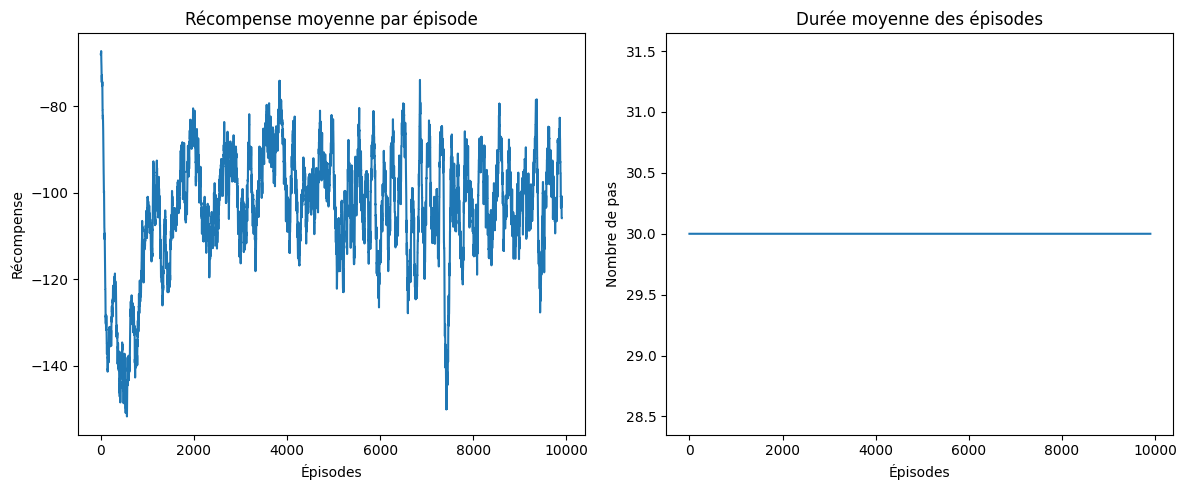

In [12]:
import matplotlib.pyplot as plt
import numpy as np


def show_results(rewards_per_episode, episode_lengths):
	def moving_average(data, window_size=100):
		return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

	plt.figure(figsize=(12, 5))
	plt.subplot(1, 2, 1)
	plt.plot(moving_average(rewards_per_episode))
	plt.title('Récompense moyenne par épisode')
	plt.xlabel('Épisodes')
	plt.ylabel('Récompense')

	plt.subplot(1, 2, 2)
	plt.plot(moving_average(episode_lengths))
	plt.title('Durée moyenne des épisodes')
	plt.xlabel('Épisodes')
	plt.ylabel('Nombre de pas')

	plt.tight_layout()
	plt.show()

show_results(rewards, lengths)

We can see with those parameters ai is not making a lot of good tries and waste its time.

In [13]:
def print_hyperparameters():
    print("🔧 Hyperparamètres de l'agent RL")
    print(f"  alpha          = {alpha:<8}  # Taux d'apprentissage (learning rate)")
    print(f"  gamma          = {gamma:<8}  # Facteur d'actualisation (discount factor)")
    print(f"  epsilon        = {epsilon:<8}  # Taux d'exploration (epsilon-greedy)")
    print(f"  epsilon_decay  = {epsilon_decay:<8}  # Décroissance d'epsilon à chaque épisode")
    print(f"  epsilon_min    = {epsilon_min:<8}  # Valeur minimale d'epsilon")
    print(f"  num_episodes   = {num_episodes:<8}  # Nombre total d'épisodes d'entraînement")
    print(f"  max_steps      = {max_steps:<8}  # Nombre max d'étapes par épisode")


print_hyperparameters()

🔧 Hyperparamètres de l'agent RL
  alpha          = 0.1       # Taux d'apprentissage (learning rate)
  gamma          = 0.99      # Facteur d'actualisation (discount factor)
  epsilon        = 0.3       # Taux d'exploration (epsilon-greedy)
  epsilon_decay  = 0.9995    # Décroissance d'epsilon à chaque épisode
  epsilon_min    = 0.01      # Valeur minimale d'epsilon
  num_episodes   = 10000     # Nombre total d'épisodes d'entraînement
  max_steps      = 30        # Nombre max d'étapes par épisode


In [14]:
def reset_training_vars():
	global q_table
	q_table = np.zeros((state_size, action_size))  


Let's change the parameters to add some randomizing

We keep all other parameters the same except Epsilon to increase randomness


In [15]:
epsilon = 0.9  # Exploration rate (epsilon-greedy), time when agent will make random decision

reset_training_vars()

q_table_path = "q_table_2.pkl"
_, rewards, lengths = train_monte_carlo(q_table_path, q_table, num_episodes, max_steps, gamma, epsilon, epsilon_min, epsilon_decay)

🚀 Aucune Q-table trouvée, entraînement en cours...
Episode 0, Total return: -93, Epsilon: 0.9000
Episode 1000, Total return: -57, Epsilon: 0.5458
Episode 2000, Total return: -48, Epsilon: 0.3310
Episode 3000, Total return: -48, Epsilon: 0.2007
Episode 4000, Total return: -48, Epsilon: 0.1217
Episode 5000, Total return: -48, Epsilon: 0.0738
Episode 6000, Total return: -30, Epsilon: 0.0448
Episode 7000, Total return: -30, Epsilon: 0.0272
Episode 8000, Total return: -39, Epsilon: 0.0165
Episode 9000, Total return: -30, Epsilon: 0.0100

⏱️ Entraînement terminé en 18.50 secondes
💾 Q-table sauvegardée


In [16]:
visualize_agent(env, q_table, 1, 1, delay=0.1)

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+




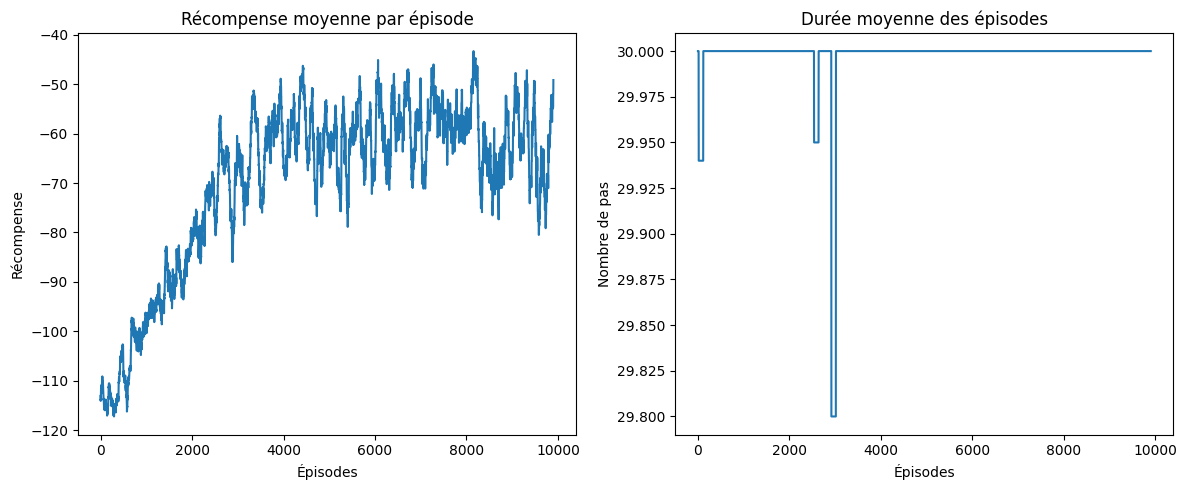

In [17]:
show_results(rewards, lengths)

Ok so now we have a little better result let's run more episodes

In [18]:
reset_training_vars()

max_steps = 100

q_table_path = "q_table_3.pkl"
_, rewards, lengths = train_monte_carlo(q_table_path, q_table, num_episodes, max_steps, gamma, epsilon, epsilon_min, epsilon_decay)

🚀 Aucune Q-table trouvée, entraînement en cours...
Episode 0, Total return: -298, Epsilon: 0.9000
Episode 1000, Total return: -442, Epsilon: 0.5458
Episode 2000, Total return: -349, Epsilon: 0.3310
Episode 3000, Total return: -505, Epsilon: 0.2007
Episode 4000, Total return: -192, Epsilon: 0.1217
Episode 5000, Total return: -118, Epsilon: 0.0738
Episode 6000, Total return: -1000, Epsilon: 0.0448
Episode 7000, Total return: -100, Epsilon: 0.0272
Episode 8000, Total return: -100, Epsilon: 0.0165
Episode 9000, Total return: -109, Epsilon: 0.0100

⏱️ Entraînement terminé en 52.99 secondes
💾 Q-table sauvegardée


🔧 Hyperparamètres de l'agent RL
  alpha          = 0.1       # Taux d'apprentissage (learning rate)
  gamma          = 0.99      # Facteur d'actualisation (discount factor)
  epsilon        = 0.9       # Taux d'exploration (epsilon-greedy)
  epsilon_decay  = 0.9995    # Décroissance d'epsilon à chaque épisode
  epsilon_min    = 0.01      # Valeur minimale d'epsilon
  num_episodes   = 10000     # Nombre total d'épisodes d'entraînement
  max_steps      = 100       # Nombre max d'étapes par épisode


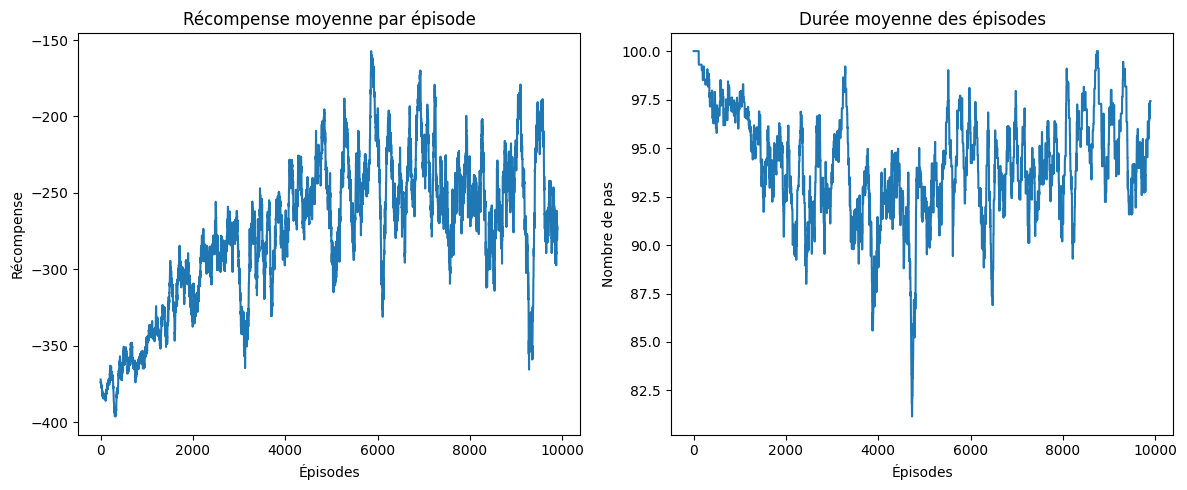

In [19]:
print_hyperparameters()
show_results(rewards, lengths)

Looks like episode cant go to the end below 90 steps so reward was biased

Let's increase number of episodes

In [20]:
reset_training_vars()

num_episodes = 30000

q_table_path = "q_table_4.pkl"
_, rewards, lengths = train_monte_carlo(q_table_path, q_table, num_episodes, max_steps, gamma, epsilon, epsilon_min, epsilon_decay)

🚀 Aucune Q-table trouvée, entraînement en cours...
Episode 0, Total return: -316, Epsilon: 0.9000
Episode 1000, Total return: -244, Epsilon: 0.5458
Episode 2000, Total return: -406, Epsilon: 0.3310
Episode 3000, Total return: -514, Epsilon: 0.2007
Episode 4000, Total return: -208, Epsilon: 0.1217
Episode 5000, Total return: -100, Epsilon: 0.0738
Episode 6000, Total return: -118, Epsilon: 0.0448
Episode 7000, Total return: -118, Epsilon: 0.0272
Episode 8000, Total return: -991, Epsilon: 0.0165
Episode 9000, Total return: -100, Epsilon: 0.0100
Episode 10000, Total return: -991, Epsilon: 0.0100
Episode 11000, Total return: -100, Epsilon: 0.0100
Episode 12000, Total return: 10, Epsilon: 0.0100
Episode 13000, Total return: -100, Epsilon: 0.0100
Episode 14000, Total return: -109, Epsilon: 0.0100
Episode 15000, Total return: -118, Epsilon: 0.0100
Episode 16000, Total return: -100, Epsilon: 0.0100
Episode 17000, Total return: -100, Epsilon: 0.0100
Episode 18000, Total return: -100, Epsilon: 0.

🔧 Hyperparamètres de l'agent RL
  alpha          = 0.1       # Taux d'apprentissage (learning rate)
  gamma          = 0.99      # Facteur d'actualisation (discount factor)
  epsilon        = 0.9       # Taux d'exploration (epsilon-greedy)
  epsilon_decay  = 0.9995    # Décroissance d'epsilon à chaque épisode
  epsilon_min    = 0.01      # Valeur minimale d'epsilon
  num_episodes   = 30000     # Nombre total d'épisodes d'entraînement
  max_steps      = 100       # Nombre max d'étapes par épisode


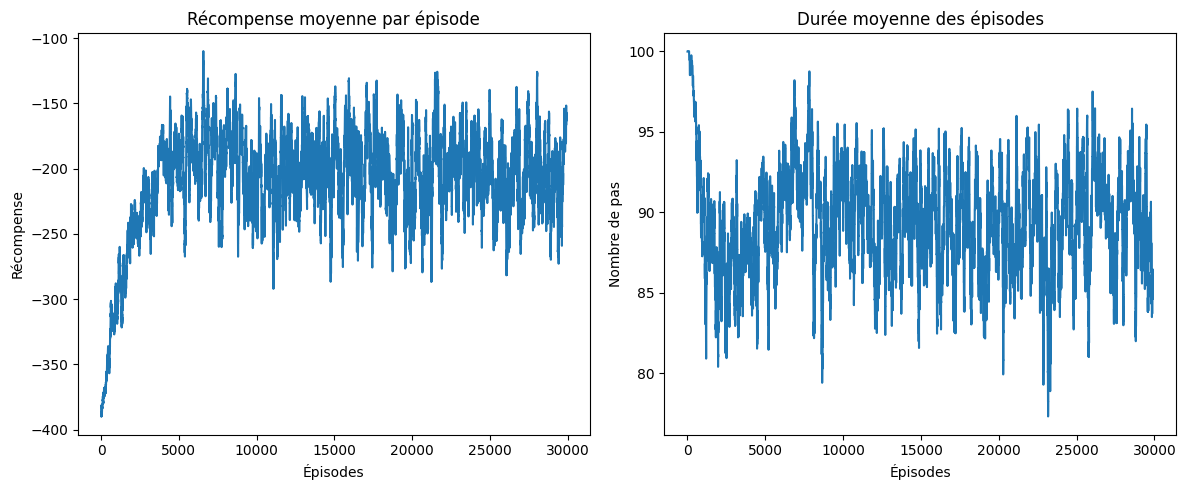

In [21]:
print_hyperparameters()
show_results(rewards, lengths)

In [22]:
reset_training_vars()

num_episodes = 5000
max_steps = 1000

q_table_path = "q_table_5.pkl"
_, rewards, lengths = train_monte_carlo(q_table_path, q_table, num_episodes, max_steps, gamma, epsilon, epsilon_min, epsilon_decay)

🚀 Aucune Q-table trouvée, entraînement en cours...
Episode 0, Total return: -3389, Epsilon: 0.9000
Episode 1000, Total return: -189, Epsilon: 0.5458
Episode 2000, Total return: -18, Epsilon: 0.3310
Episode 3000, Total return: -41, Epsilon: 0.2007
Episode 4000, Total return: 3, Epsilon: 0.1217

⏱️ Entraînement terminé en 30.34 secondes
💾 Q-table sauvegardée


🔧 Hyperparamètres de l'agent RL
  alpha          = 0.1       # Taux d'apprentissage (learning rate)
  gamma          = 0.99      # Facteur d'actualisation (discount factor)
  epsilon        = 0.9       # Taux d'exploration (epsilon-greedy)
  epsilon_decay  = 0.9995    # Décroissance d'epsilon à chaque épisode
  epsilon_min    = 0.01      # Valeur minimale d'epsilon
  num_episodes   = 5000      # Nombre total d'épisodes d'entraînement
  max_steps      = 1000      # Nombre max d'étapes par épisode


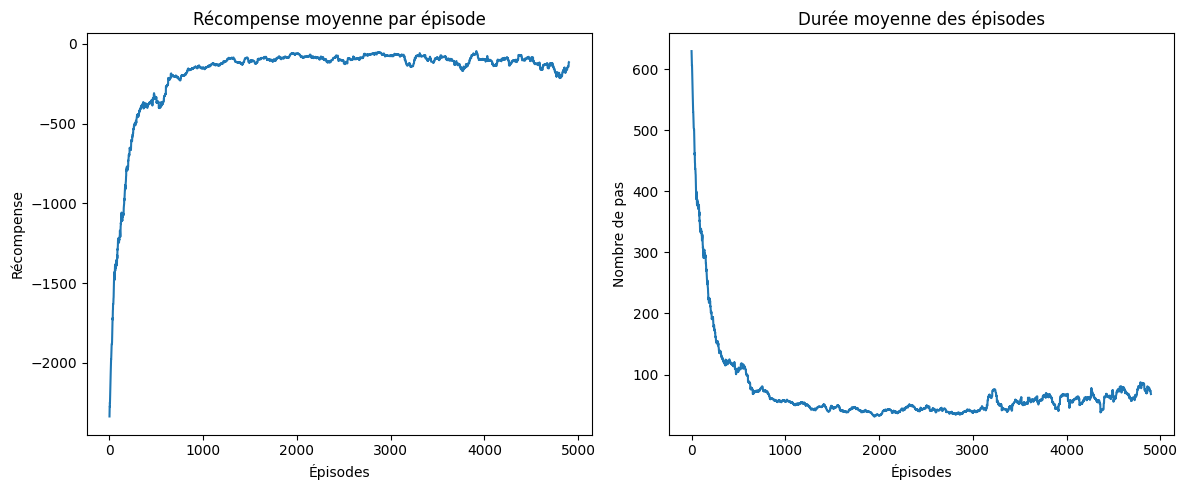

In [23]:
print_hyperparameters()
show_results(rewards, lengths)

Now we start to come closer to an efficient agent

Let double the episodes to see if it's going better with time

In [24]:
reset_training_vars()

num_episodes = 10000

q_table_path = "q_table_6.pkl"
_, rewards, lengths = train_monte_carlo(q_table_path, q_table, num_episodes, max_steps, gamma, epsilon, epsilon_min, epsilon_decay)

🚀 Aucune Q-table trouvée, entraînement en cours...
Episode 0, Total return: -3799, Epsilon: 0.9000
Episode 1000, Total return: -587, Epsilon: 0.5458
Episode 2000, Total return: -99, Epsilon: 0.3310
Episode 3000, Total return: -638, Epsilon: 0.2007
Episode 4000, Total return: 4, Epsilon: 0.1217
Episode 5000, Total return: -7, Epsilon: 0.0738
Episode 6000, Total return: -4, Epsilon: 0.0448
Episode 7000, Total return: -12, Epsilon: 0.0272
Episode 8000, Total return: -717, Epsilon: 0.0165
Episode 9000, Total return: -277, Epsilon: 0.0100

⏱️ Entraînement terminé en 94.99 secondes
💾 Q-table sauvegardée


🔧 Hyperparamètres de l'agent RL
  alpha          = 0.1       # Taux d'apprentissage (learning rate)
  gamma          = 0.99      # Facteur d'actualisation (discount factor)
  epsilon        = 0.9       # Taux d'exploration (epsilon-greedy)
  epsilon_decay  = 0.9995    # Décroissance d'epsilon à chaque épisode
  epsilon_min    = 0.01      # Valeur minimale d'epsilon
  num_episodes   = 10000     # Nombre total d'épisodes d'entraînement
  max_steps      = 1000      # Nombre max d'étapes par épisode


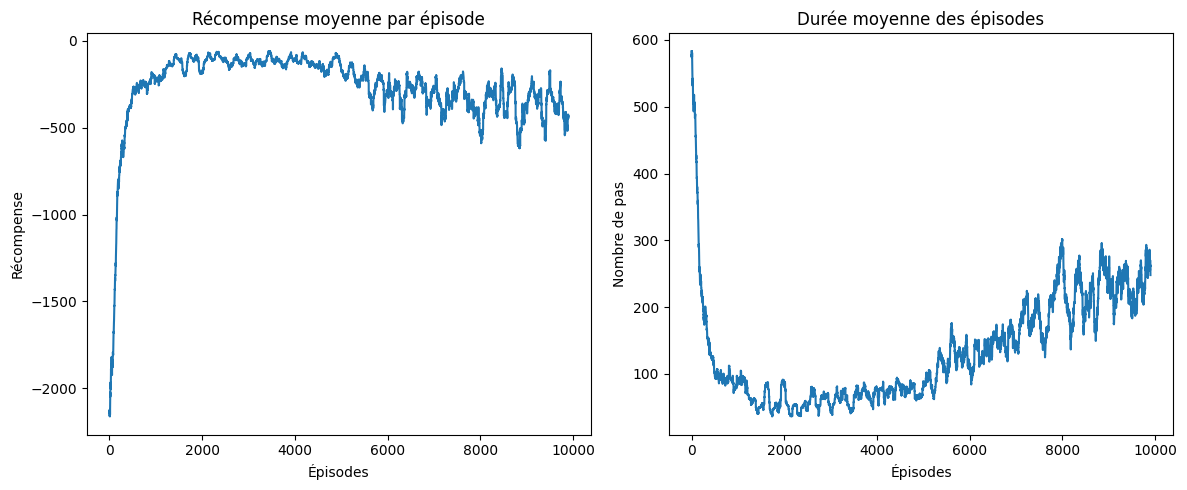

In [25]:
print_hyperparameters()
show_results(rewards, lengths)

🚀 Aucune Q-table trouvée, entraînement en cours...
Episode 0, Total return: -3925, Epsilon: 1.0000
Episode 1000, Total return: -62, Epsilon: 0.3677
Episode 2000, Total return: -111, Epsilon: 0.1352
Episode 3000, Total return: 6, Epsilon: 0.0497
Episode 4000, Total return: -2317, Epsilon: 0.0183
Episode 5000, Total return: -828, Epsilon: 0.0100
Episode 6000, Total return: 7, Epsilon: 0.0100
Episode 7000, Total return: -647, Epsilon: 0.0100
Episode 8000, Total return: -239, Epsilon: 0.0100
Episode 9000, Total return: -141, Epsilon: 0.0100
Episode 10000, Total return: -1072, Epsilon: 0.0100
Episode 11000, Total return: 4, Epsilon: 0.0100
Episode 12000, Total return: 9, Epsilon: 0.0100
Episode 13000, Total return: -1027, Epsilon: 0.0100
Episode 14000, Total return: 4, Epsilon: 0.0100
Episode 15000, Total return: -633, Epsilon: 0.0100
Episode 16000, Total return: -682, Epsilon: 0.0100
Episode 17000, Total return: 10, Epsilon: 0.0100
Episode 18000, Total return: 11, Epsilon: 0.0100
Episode 1

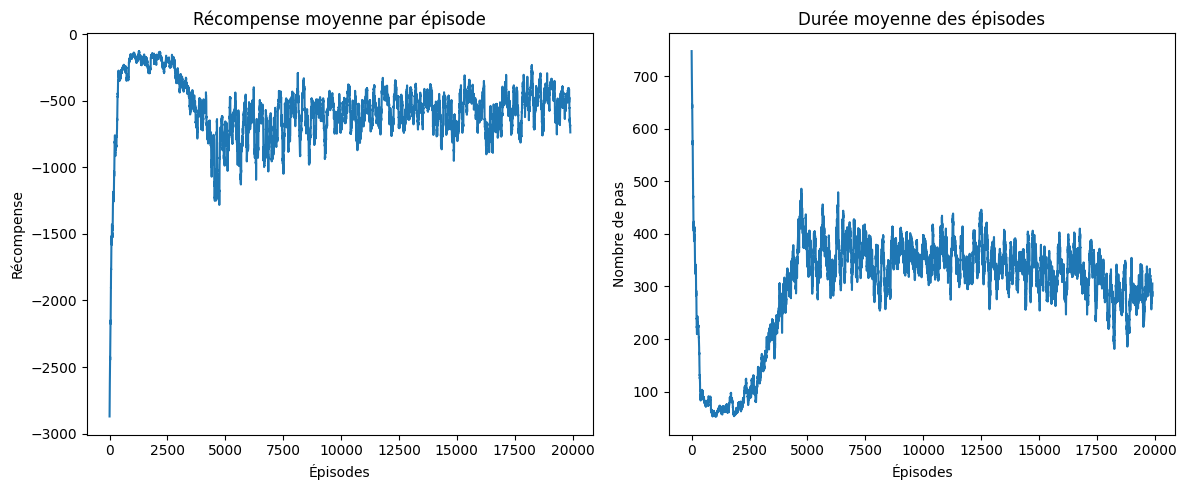

In [26]:
reset_training_vars()

epsilon = 1
num_episodes = 20000
epsilon_decay = 0.999

q_table_path = "q_table_7.pkl"
_, rewards, lengths = train_monte_carlo(q_table_path, q_table, num_episodes, max_steps, gamma, epsilon, epsilon_min, epsilon_decay)


print_hyperparameters()
show_results(rewards, lengths)